In [1]:
# All packages
import os
from pathlib import Path
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import hashlib

def imread_unicode(path):
    """cv2.imread falha em caminhos com acentos/caracteres não-ASCII no Windows
    (ex: 'Visão Computacional'). Contorna lendo os bytes manualmente e decodificando."""
    data = np.fromfile(path, dtype=np.uint8)
    return cv2.imdecode(data, cv2.IMREAD_COLOR)

def show_image(img_bgr, title=None, ax=None):
    """Exibe uma imagem lida com cv2 (BGR) usando matplotlib.
    Substitui cv2_imshow, que só funciona no Google Colab."""
    target = ax if ax is not None else plt
    target.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    if ax is not None:
        ax.axis("off")
        if title:
            ax.set_title(title, fontsize=9)
    else:
        plt.axis("off")
        if title:
            plt.title(title)

In [2]:
# Basic paths
DATA_DIR = Path(r"D:\Visão Computacional\Bases\Agricultural Pests Image Dataset")

CLASSES = sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()])
print(f"{len(CLASSES)} classes:", CLASSES)

12 classes: ['ants', 'bees', 'beetle', 'catterpillar', 'earthworms', 'earwig', 'grasshopper', 'moth', 'slug', 'snail', 'wasp', 'weevil']


In [3]:
VALID_SUFIX = {".jpg", ".jpeg", ".png"}

# Address dictionaries
records = [
    {"file_path": str(f), "label": cls}
    for cls in CLASSES
    for f in (DATA_DIR / cls).iterdir()
    if f.suffix.lower() in VALID_SUFIX
]

df = pd.DataFrame(records)
print(df.shape)
df.head()

(5494, 2)


,file_path,label
0,D:\Visão Computacional\Bases\Agricultural Pest...,ants
1,D:\Visão Computacional\Bases\Agricultural Pest...,ants
2,D:\Visão Computacional\Bases\Agricultural Pest...,ants
3,D:\Visão Computacional\Bases\Agricultural Pest...,ants
4,D:\Visão Computacional\Bases\Agricultural Pest...,ants


In [4]:
# Metadata extraction
def read_info(path):
    img = imread_unicode(path)
    if img is None:
        return pd.Series({"height": np.nan, "width": np.nan, "channels": np.nan})
    h,w,c = img.shape
    return pd.Series({"height": h, "width": w, "channels": c})

df["file_name"] = df["file_path"].apply(lambda p: Path(p).stem)
df[["height", "width", "channels"]] = df["file_path"].apply(read_info)
df["file_type"] = df["file_path"].apply(lambda p: Path(p).suffix.lower())
df["file_size_kb"] = df["file_path"].apply(lambda p: Path(p).stat().st_size / 1024)

corrupted_files = df[["height", "width", "channels"]].isna().sum(axis=1)
print(f"{corrupted_files} corrupted files.")

df = df.dropna(subset=["height", "width", "channels"]).reset_index(drop=True)
df["height"] = df["height"].astype(int)
df["width"] = df["width"].astype(int)
df["channels"] = df["channels"].astype(int)

df.head()

0       0
1       0
2       0
3       0
4       0
       ..
5489    0
5490    0
5491    0
5492    0
5493    0
Length: 5494, dtype: int64 corrupted files.


,file_path,label,file_name,height,width,channels,file_type,file_size_kb
0,D:\Visão Computacional\Bases\Agricultural Pest...,ants,ants (1),288,300,3,.jpg,30.736328
1,D:\Visão Computacional\Bases\Agricultural Pest...,ants,ants (1),204,300,3,.png,109.057617
2,D:\Visão Computacional\Bases\Agricultural Pest...,ants,ants (10),225,300,3,.jpg,22.416992
3,D:\Visão Computacional\Bases\Agricultural Pest...,ants,ants (100),283,300,3,.jpg,11.976562
4,D:\Visão Computacional\Bases\Agricultural Pest...,ants,ants (101),208,300,3,.jpg,17.363281


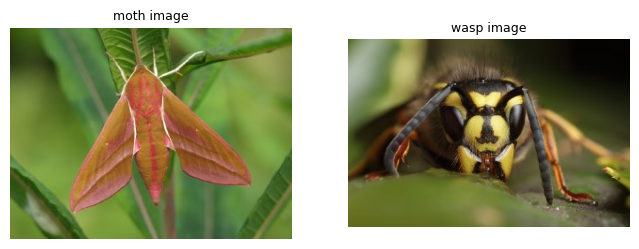

In [5]:
# Testing image print

fig, axes = plt.subplots(1,2,figsize=(8,4))

img_test = df.sample(1, random_state=14).iloc[0] # Returns a line, not the dataframe
img_test2 = df.sample(1, random_state=17).iloc[0] 

show_image(imread_unicode(img_test["file_path"]), title=f"{img_test.label} image", ax=axes[0])
show_image(imread_unicode(img_test2["file_path"]), title=f"{img_test2.label} image", ax=axes[1])

plt.show()

In [6]:
# Basic Statistics
#df.describe()

imgs_count = len(df)
print(f"\nTotal images: {imgs_count}")

# File type counting
print("\nTypes counting:")
print(df["file_type"].value_counts())

# Images per class
print("\nImages per class:")
print(df["label"].value_counts())



Total images: 5494

Types counting:
file_type
.jpg    5485
.png       9
Name: count, dtype: int64

Images per class:
label
bees            500
snail           500
ants            499
wasp            498
moth            497
grasshopper     485
weevil          485
earwig          466
catterpillar    434
beetle          416
slug            391
earthworms      323
Name: count, dtype: int64


In [7]:
# Detecção de duplicatas (mesmo hash de arquivo)
df["hash"] = df["file_path"].apply(lambda p: hashlib.md5(open(p,"rb").read()).hexdigest())

duplicates = df["hash"].duplicated(keep=False).sum()

print(f"\nDuplicates: {duplicates}")

dup_df = df[df["hash"].duplicated(keep=False)].sort_values("hash")
print(dup_df[["file_name"]])

for h, group in dup_df.groupby("hash"):
    print(f"\nHash: {h} ({len(group)} arquivos)")
    print(group[["file_name"]])

print("\n")

# Duplicatas cruzando classes (checagem formal, não só visual)
cross_class = dup_df.groupby("hash")["label"].nunique()
n_cross = (cross_class > 1).sum()
print(f"Grupos de duplicata: {cross_class.shape[0]}")
print(f"Grupos que cruzam classes diferentes: {n_cross}")

if n_cross > 0:
    print("\nGrupos problemáticos (mesma imagem em classes diferentes):")
    print(dup_df[dup_df["hash"].isin(cross_class[cross_class > 1].index)][["file_name", "label", "hash"]])
else:
    print("Nenhuma duplicata cruza classes.")


Duplicates: 12
         file_name
5018  Weevil (108)
5022  Weevil (111)
5090  Weevil (173)
5096  Weevil (179)
2418  earwig (320)
2424  earwig (326)
4540    wasp (527)
4547    wasp (534)
5117  Weevil (198)
5118  Weevil (199)
1017  beetle (115)
1018  beetle (116)

Hash: 02560b836a94a38813f16c366684b474 (2 arquivos)
         file_name
5018  Weevil (108)
5022  Weevil (111)

Hash: 34fb17a58a2086464ce2bce96bc037ff (2 arquivos)
         file_name
5090  Weevil (173)
5096  Weevil (179)

Hash: 420cf91a85385cdbb15f659e44e12081 (2 arquivos)
         file_name
2418  earwig (320)
2424  earwig (326)

Hash: 47afb27cb1a9fd5ef2424d6ee80a4e1e (2 arquivos)
       file_name
4540  wasp (527)
4547  wasp (534)

Hash: b3b08f0b14d4a47bdfc6156c0e5fe9ec (2 arquivos)
         file_name
5117  Weevil (198)
5118  Weevil (199)

Hash: fab7df2b55b587e104e12ddf175d1f82 (2 arquivos)
         file_name
1017  beetle (115)
1018  beetle (116)


Grupos de duplicata: 6
Grupos que cruzam classes diferentes: 0
Nenhuma duplicata 

In [8]:
# Estatísticas de dimensão e tamanho de arquivo
df["aspect_ratio"] = df["width"] / df["height"]

print("Describe geral (numéricas):")
print(df[["height", "width", "aspect_ratio", "file_size_kb"]].describe())

print("\nDesbalanceamento de classes (contagem max/min):")
counts = df["label"].value_counts()
print(f"Max: {counts.idxmax()} ({counts.max()}) | Min: {counts.idxmin()} ({counts.min()}) | Ratio: {counts.max() / counts.min():.2f}x")

print("\nEstatísticas por classe (média/desvio):")
per_class = df.groupby("label")[["height", "width", "aspect_ratio", "file_size_kb"]].agg(["mean", "std"])
print(per_class)

print("\nResolução extrema:")
print(f"Menor altura: {df.loc[df['height'].idxmin(), ['file_name', 'label', 'height', 'width']].to_dict()}")
print(f"Maior altura: {df.loc[df['height'].idxmax(), ['file_name', 'label', 'height', 'width']].to_dict()}")
print(f"Menor largura: {df.loc[df['width'].idxmin(), ['file_name', 'label', 'height', 'width']].to_dict()}")
print(f"Maior largura: {df.loc[df['width'].idxmax(), ['file_name', 'label', 'height', 'width']].to_dict()}")

print("\nArquivo maior/menor em disco:")
print(f"Menor: {df.loc[df['file_size_kb'].idxmin(), ['file_name', 'label', 'file_size_kb']].to_dict()}")
print(f"Maior: {df.loc[df['file_size_kb'].idxmax(), ['file_name', 'label', 'file_size_kb']].to_dict()}")

print("\nContagem de canais (esperado: tudo 3, RGB):")
print(df["channels"].value_counts())

Describe geral (numéricas):
            height        width  aspect_ratio  file_size_kb
count  5494.000000  5494.000000   5494.000000   5494.000000
mean    225.188569   291.600837      1.344201     19.092828
std      40.589002    27.636544      0.287337      8.246686
min      88.000000    92.000000      0.306667      3.761719
25%     200.000000   300.000000      1.271186     13.817139
50%     213.500000   300.000000      1.408451     17.638184
75%     236.000000   300.000000      1.500000     22.635498
max     512.000000   512.000000      3.409091    177.037109

Desbalanceamento de classes (contagem max/min):
Max: bees (500) | Min: earthworms (323) | Ratio: 1.55x

Estatísticas por classe (média/desvio):
                  height                  width            aspect_ratio  \
                    mean        std        mean        std         mean   
label                                                                     
ants          219.521042  35.208744  295.799599  18.433423    

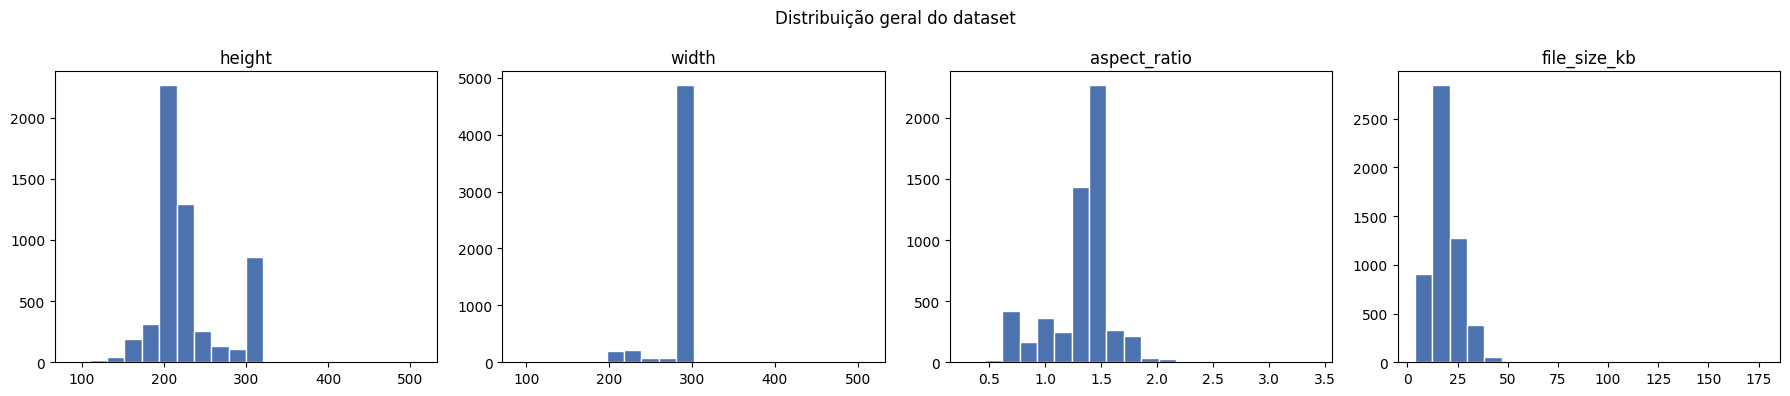

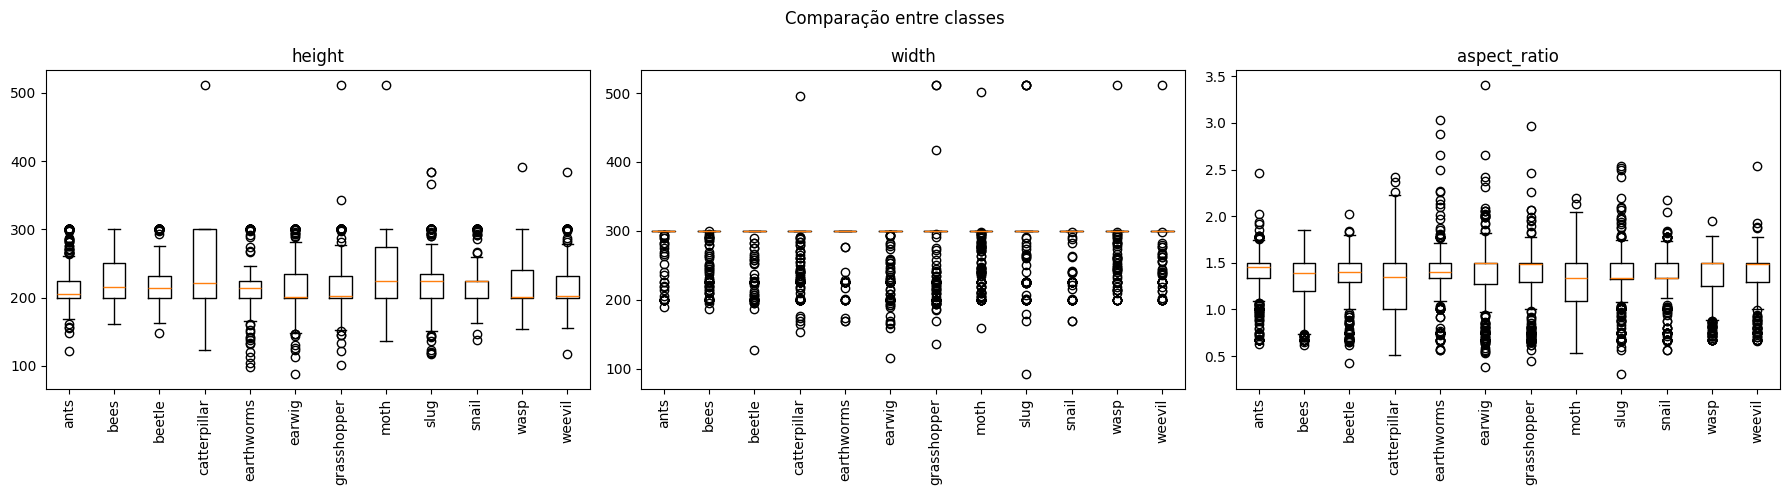

In [13]:
# Histogramas de dimensão e resolução

# Distribuição geral do dataset inteiro
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes, ["height", "width", "aspect_ratio", "file_size_kb"]):
    ax.hist(df[col], bins=20, color="#4C72B0", edgecolor="white")
    ax.set_title(col)
plt.suptitle("Distribuição geral do dataset")
plt.tight_layout()
plt.show()

# Comparação entre classes mostrando também a variação interna de cada uma
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, ["height", "width", "aspect_ratio"]):
    data = [df.loc[df["label"] == c, col] for c in CLASSES]
    ax.boxplot(data, tick_labels=CLASSES)
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=90)
plt.suptitle("Comparação entre classes")
plt.tight_layout()
plt.show()

In [10]:
# Brilho via luminância perceptual
def luminance_stats(path):
    img = imread_unicode(path)
    if img is None:
        return pd.Series({"luminance_mean": np.nan, "luminance_std": np.nan})
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)  # 0.114*B + 0.587*G + 0.299*R
    return pd.Series({"luminance_mean": gray.mean(), "luminance_std": gray.std()})

df[["luminance_mean", "luminance_std"]] = df["file_path"].apply(luminance_stats)

print("Describe geral (luminância):")
print(df[["luminance_mean", "luminance_std"]].describe())

print("\nLuminância média por classe:")
print(df.groupby("label")[["luminance_mean", "luminance_std"]].mean())

print("\nImagens mais escuras/claras por luminância (top 5):")
print("Mais escuras:")
print(df.nsmallest(5, "luminance_mean")[["file_name", "luminance_mean"]])
print("\nMais claras:")
print(df.nlargest(5, "luminance_mean")[["file_name", "luminance_mean"]])

Describe geral (luminância):
       luminance_mean  luminance_std
count     5494.000000    5494.000000
mean       122.841019      47.667114
std         36.245157      13.587075
min          5.560368      11.079954
25%         99.376957      37.959347
50%        122.058951      46.758408
75%        144.487913      56.271012
max        245.155796     100.151901

Luminância média por classe:
              luminance_mean  luminance_std
label                                      
ants              138.076197      46.369088
bees              119.163992      50.231151
beetle            120.329137      46.951342
catterpillar      115.708618      46.869000
earthworms        114.481029      46.628387
earwig            129.193974      46.676170
grasshopper       112.895622      44.643620
moth              129.423511      50.037512
slug              111.942542      46.990362
snail             119.838728      48.762341
wasp              123.369258      50.605475
weevil            133.496214      46

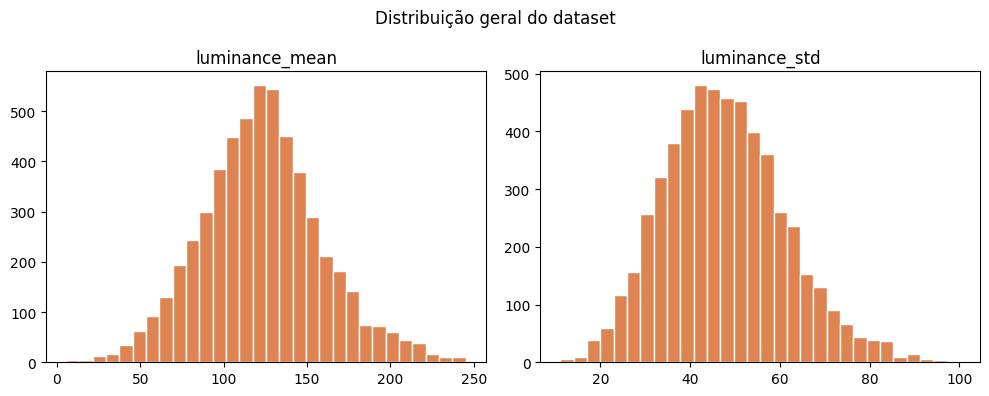

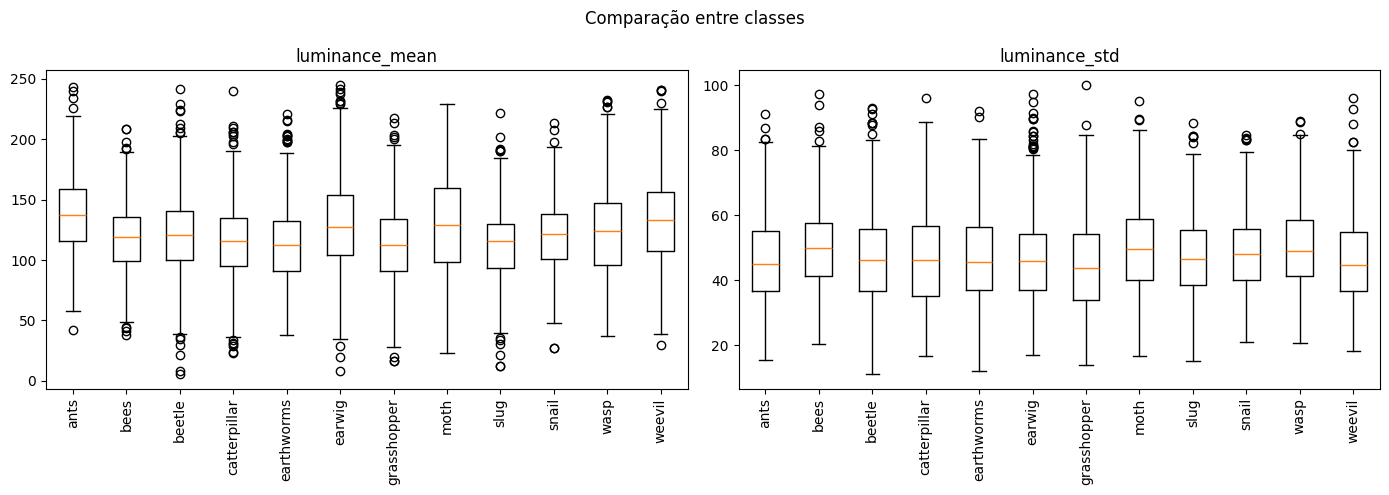

In [11]:
# Histogramas de luminância

# Distribuição geral do dataset inteiro
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, col in zip(axes, ["luminance_mean", "luminance_std"]):
    ax.hist(df[col], bins=30, color="#DD8452", edgecolor="white")
    ax.set_title(col)
plt.suptitle("Distribuição geral do dataset")
plt.tight_layout()
plt.show()

# Comparação entre classes mostrando também a variação interna de cada uma
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col in zip(axes, ["luminance_mean", "luminance_std"]):
    data = [df.loc[df["label"] == c, col] for c in CLASSES]
    ax.boxplot(data, tick_labels=CLASSES)
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=90)
plt.suptitle("Comparação entre classes")
plt.tight_layout()
plt.show()